<a href="https://colab.research.google.com/github/matheuspaleari/Machine_Learning/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Parte 1 - Importando bibliotecas

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn.csv to customer_churn.csv


In [ ]:
df = pd.read_csv("customer_churn.csv")

In [ ]:
### lendo as colunas do data set
print(df.columns)

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')


In [ ]:
np.mean(df["Total Spend"])

np.float64(541.0233790039457)

#Parte 2 - Carregando os dados

In [ ]:
df = pd.read_csv("customer_churn.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


#Parte 3 - Entendendo os dados

In [ ]:
df.shape

(64374, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


#Parte 4 - Análise Exploratória (EDA)


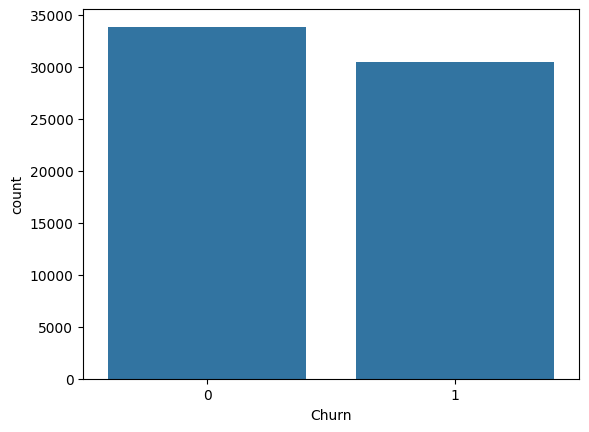

In [ ]:
sns.countplot(x='Churn', data=df)
plt.show()

#Parte 5 - Limpeza de Dados

In [ ]:
df.isnull().sum()
df.dropna(inplace=True)

#Parte 6 - Transformação

In [ ]:
df.dtypes

,0
CustomerID,int64
Age,int64
Gender,object
Tenure,int64
Usage Frequency,int64
Support Calls,int64
Payment Delay,int64
Subscription Type,object
Contract Length,object
Total Spend,int64


In [ ]:
### Ajustando todas as colunas para int64
le = LabelEncoder()

colunas_categoricas = [
    'Gender',
    'Subscription Type',
    'Contract Length'
]

for coluna in colunas_categoricas:
    df[coluna] = le.fit_transform(df[coluna])

In [ ]:
df.dtypes

,0
CustomerID,int64
Age,int64
Gender,int64
Tenure,int64
Usage Frequency,int64
Support Calls,int64
Payment Delay,int64
Subscription Type,int64
Contract Length,int64
Total Spend,int64


In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,33881
1,30493


In [ ]:
X = df.drop(['CustomerID', 'Churn'], axis=1)

y = df['Churn']

In [ ]:
###separando base de treino e base de teste.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
##padronização
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
### treinando regressão lógica
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = modelo.predict(X_test_scaled)

In [ ]:
print("Acurácia:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Acurácia: 0.8306019417475728
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6793
           1       0.81      0.83      0.82      6082

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



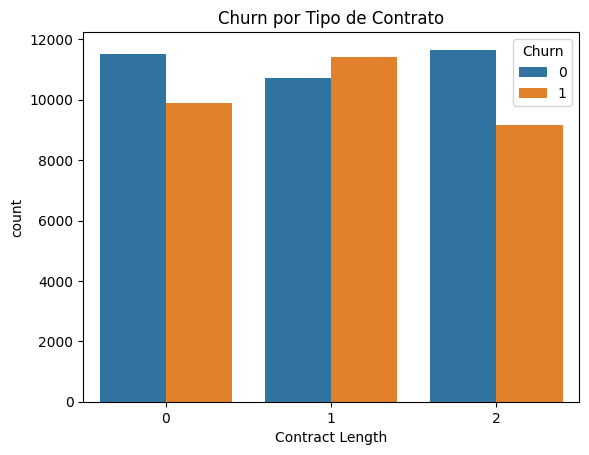

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x='Contract Length',
    hue='Churn'
)

plt.title("Churn por Tipo de Contrato")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy: 0.9994563106796116
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875

